First thing, we need a reference spectrum. 

In [23]:
import pandas as pd

# Load the CSV file
df_es = pd.read_csv('Es_spectrum.csv')
wave_Es = df_es['wave'].values
Es = df_es['Es'].values

In [2]:
import earthaccess
import xarray as xr
auth = earthaccess.login()
# are we authenticated?
if not auth.authenticated:
    # ask for credentials and persist them in a .netrc file
    auth.login(strategy="interactive", persist=True)

Enter your Earthdata Login username:  ryan.vandermeulen@noaa.gov
Enter your Earthdata password:  ········


In [3]:
import earthaccess
results = earthaccess.search_data(
    short_name = "PACE_OCI_L3M_KD",
    temporal = ("2024-09-01", "2024-09-30"),
    granule_name="*.MO.*.0p1deg.*"
)

In [4]:
# Create a fileset
fileset = earthaccess.open(results);

import h5netcdf
with h5netcdf.File(fileset[0]) as file:
    groups = list(file)
groups

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

['processing_control', 'wavelength', 'Kd', 'lat', 'lon', 'palette']

In [5]:
# ---- Load Libraries ----
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cartopy
import cartopy.crs as ccrs
from matplotlib import colors
from scipy.integrate import trapezoid

In [6]:
# Load relevant datasets
dataset = xr.open_dataset(fileset[0])

# Assign core variables
latitude = dataset["lat"]
longitude = dataset["lon"]
Kd = dataset["Kd"]
wavelengths = dataset["wavelength"]

In [7]:
Kd_490 = Kd.sel(wavelength=490.0, method='nearest')

<xarray.DataArray 'Kd' (lat: 1800, lon: 3600)> Size: 26MB
[6480000 values with dtype=float32]
Coordinates:
    wavelength  float64 8B 490.0
  * lat         (lat) float32 7kB 89.95 89.85 89.75 ... -89.75 -89.85 -89.95
  * lon         (lon) float32 14kB -179.9 -179.9 -179.8 ... 179.8 179.9 180.0
Attributes:
    long_name:      Diffuse attenuation coefficient
    units:          m^-1
    valid_min:      50
    valid_max:      30000
    reference:      Lee, Z.P., M. Darecki, K.L. Carder, C.O.Davis, D. Stramsk...
    display_scale:  log
    display_min:    0.01
    display_max:    5.0

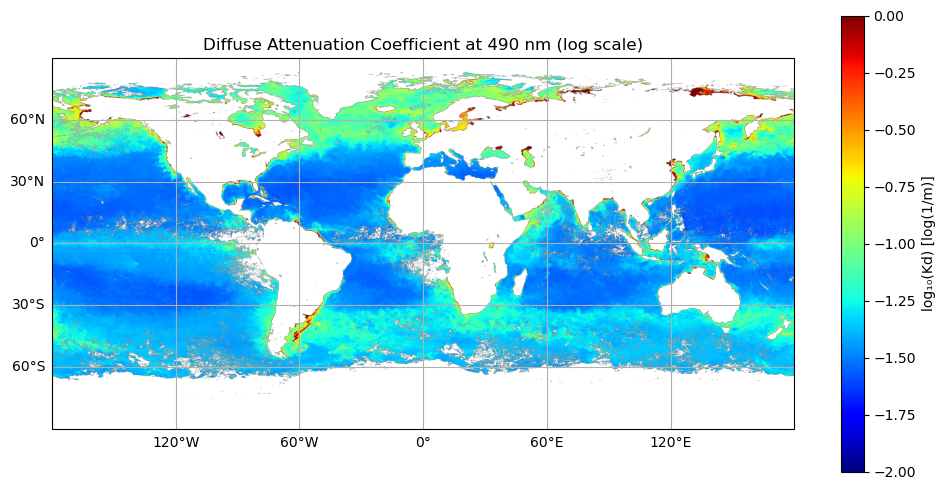

In [12]:
# Clean the data: mask invalid or non-positive Kd values
Kd_490 = Kd.sel(wavelength=490.0, method="nearest")
Kd_490_clean = Kd_490.where(Kd_490 > 0)  # xarray masking

# Convert to log scale
Kd_log = np.log10(Kd_490_clean)
Kd_log = np.flipud(Kd_log)

# Plot with imshow
plt.figure(figsize=(10, 5))
ax = plt.axes(projection=cartopy.crs.PlateCarree())
ax.gridlines(draw_labels={"bottom": "x", "left": "y"})
plt.imshow(
    Kd_log,
    origin='lower',
    cmap='jet',
    extent=[longitude.min(), longitude.max(), latitude.min(), latitude.max()],
    vmin=-2, vmax=0  # e.g., log10(0.01) to log10(1.0)
)
plt.colorbar(label='log₁₀(Kd) [log(1/m)]')
plt.title('Diffuse Attenuation Coefficient at 490 nm (log scale)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

In [33]:
# target coordinates
target_lat = -45.0
target_lon = -60.0

# get lat/lon arrays
lat_vals = latitude.values  # shape (1800,)
lon_vals = longitude.values  # shape (3600,)

# create 2D meshgrid of coordinate distances
lat_grid, lon_grid = np.meshgrid(lat_vals, lon_vals, indexing='ij')

# calculate distance from target point (Manhattan distance or Euclidean)
dist = np.abs(lat_grid - target_lat) + np.abs(lon_grid - target_lon)  # Manhattan
# or dist = np.sqrt((lat_grid - target_lat)**2 + (lon_grid - target_lon)**2)  # Euclidean

# find the indices of the minimum distance
i, j = np.unravel_index(np.argmin(dist), dist.shape)

Kd_pixel = Kd.isel(lat=i, lon=j)  # shape: (wavelength,)
wavelengths_vals = Kd_pixel['wavelength'].values
Kd_vals = Kd_pixel.values

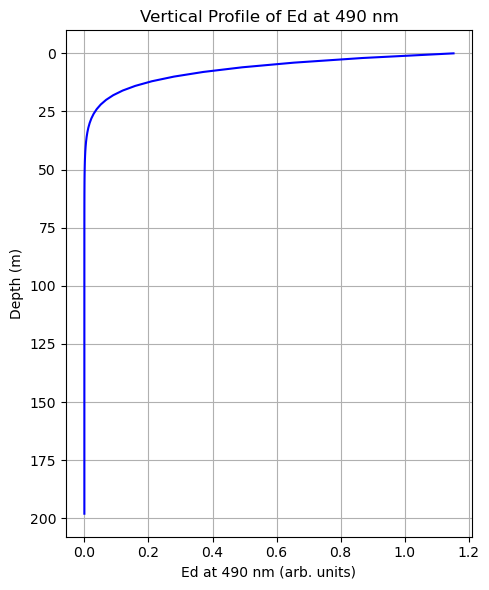

In [34]:
# Find index of 490 nm (or nearest)
idx_490 = np.abs(wavelengths_vals - 490).argmin()
Kd_490 = Kd_vals[idx_490]
Ed_0 = Es[idx_490]

# Create depth array (e.g., 0 to 50 m in 0.5 m steps)
depths = np.arange(0, 200, 2)

# Compute Ed at each depth
Ed_profile = Ed_0 * np.exp(-Kd_490 * depths)

plt.figure(figsize=(5, 6))
plt.plot(Ed_profile, depths, '-b')
plt.gca().invert_yaxis()  # Depth increases downward
plt.xlabel("Ed at 490 nm (arb. units)")
plt.ylabel("Depth (m)")
plt.title("Vertical Profile of Ed at 490 nm")
plt.grid(True)
plt.tight_layout()
plt.show()

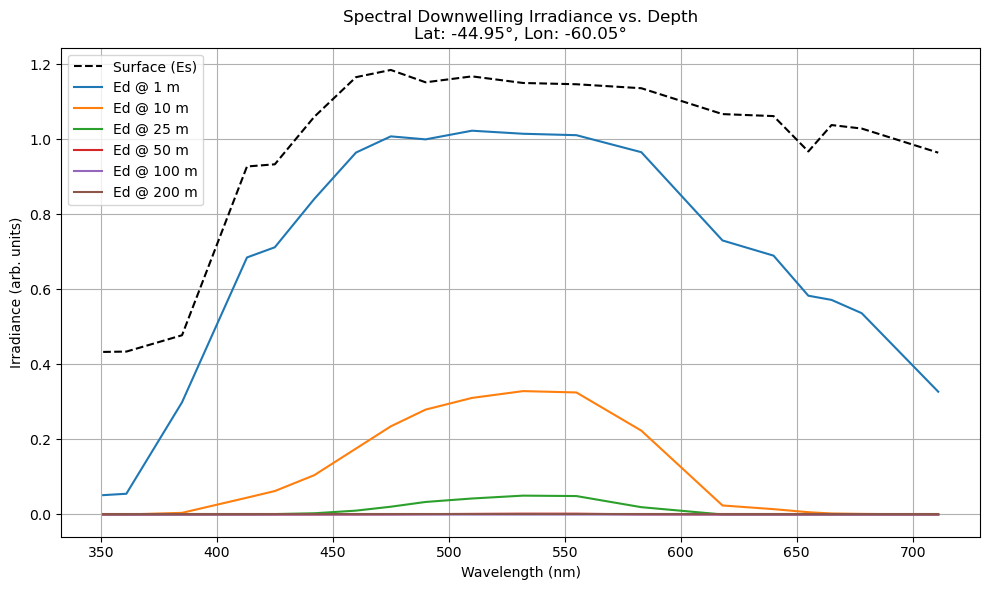

In [35]:
depths = [1, 10, 25, 50, 100, 200]
attenuated_spectra = {}

for z in depths:
    attenuated_spectra[z] = Es * np.exp(-Kd_vals * z)

plt.figure(figsize=(10, 6))

# Plot Es (surface spectrum)
plt.plot(wavelengths_vals, Es, 'k--', label='Surface (Es)')

# Plot each Ed(z)
for z in depths:
    plt.plot(wavelengths_vals, attenuated_spectra[z], label=f'Ed @ {z} m')

lat_val = latitude[i].item()
lon_val = longitude[j].item()

plt.xlabel("Wavelength (nm)")
plt.ylabel("Irradiance (arb. units)")
plt.title(f"Spectral Downwelling Irradiance vs. Depth\nLat: {lat_val:.2f}°, Lon: {lon_val:.2f}°")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()